In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


In [17]:
import sys
!{sys.executable} -m pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
print("imbalanced-learn ready!")

imbalanced-learn ready!


'e:\Minor' is not recognized as an internal or external command,
operable program or batch file.


In [18]:
df = pd.read_csv("../data/raw/kidney_disease.csv")

In [19]:
# Drop ID
df.drop(columns=['id'], inplace=True, errors='ignore')

# Strip all whitespace from string cells
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Replace blanks and nan strings with NaN
df.replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan}, inplace=True)

# Fix classification typos
df['classification'] = df['classification'].replace({'ckd\t': 'ckd', '\tckd': 'ckd'})

# Force numeric columns to float
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc',
                'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Force categorical columns to plain object dtype
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in categorical_cols:
    df[col] = df[col].astype(str).replace({'nan': np.nan, 'None': np.nan})
    df[col] = df[col].str.strip().str.lower()

print("Cleaning done!")
print(f"Missing values: {df.isnull().sum().sum()}")

Cleaning done!
Missing values: 1012


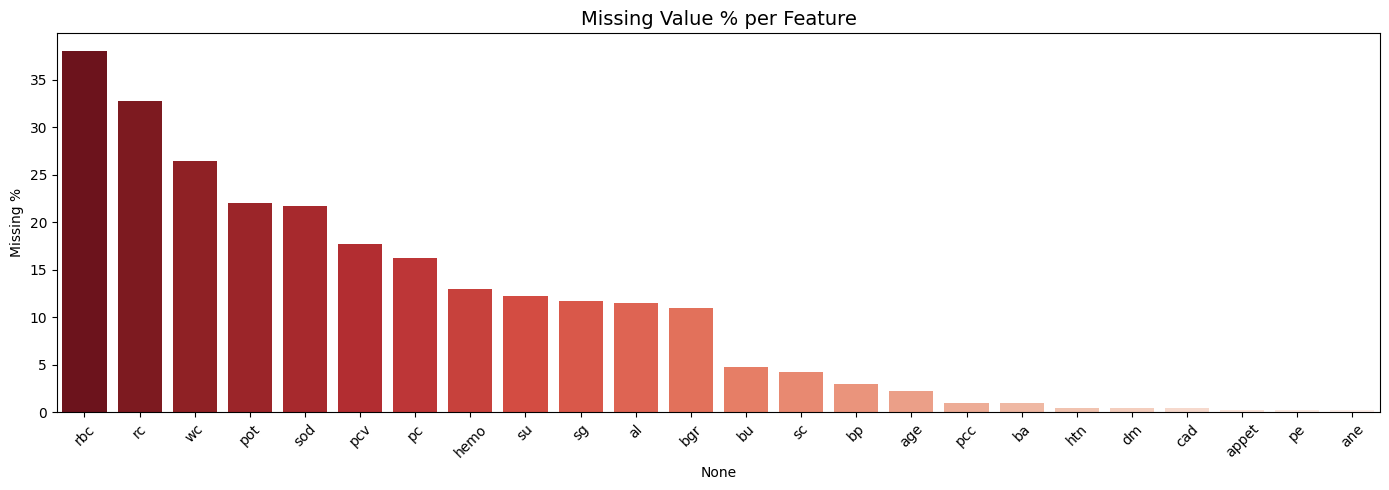

In [20]:
plt.figure(figsize=(14, 5))
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
sns.barplot(x=missing_pct.index, y=missing_pct.values, palette='Reds_r')
plt.title('Missing Value % per Feature', fontsize=14)
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc',
                'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].dropna().mode()[0])

print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


In [22]:
le = LabelEncoder()
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

print(f"\n✅ Encoding done!")
print(f"Class distribution:\n{df['classification'].value_counts()}")

  rbc: {'abnormal': np.int64(0), 'normal': np.int64(1)}
  pc: {'abnormal': np.int64(0), 'normal': np.int64(1)}
  pcc: {'notpresent': np.int64(0), 'present': np.int64(1)}
  ba: {'notpresent': np.int64(0), 'present': np.int64(1)}
  htn: {'no': np.int64(0), 'yes': np.int64(1)}
  dm: {'no': np.int64(0), 'yes': np.int64(1)}
  cad: {'no': np.int64(0), 'yes': np.int64(1)}
  appet: {'good': np.int64(0), 'poor': np.int64(1)}
  pe: {'no': np.int64(0), 'yes': np.int64(1)}
  ane: {'no': np.int64(0), 'yes': np.int64(1)}

✅ Encoding done!
Class distribution:
classification
1    250
0    150
Name: count, dtype: int64


In [23]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after: ", df.duplicated().sum())
print("Shape:", df.shape)

Duplicates before: 0
Duplicates after:  0
Shape: (400, 25)


In [24]:
print("=" * 50)
print("✅ CHECKLIST")
print("=" * 50)
print(f"[{'✓' if df.isnull().sum().sum()==0 else '✗'}] Missing values handled")
print(f"[✓] Categorical features encoded")
print(f"[{'✓' if set(df['classification'].unique())=={0,1} else '✗'}] Target: ckd=1, notckd=0")
print(f"[{'✓' if df.select_dtypes(include='object').shape[1]==0 else '✗'}] Fully numerical")
print(f"[{'✓' if df.duplicated().sum()==0 else '✗'}] No duplicates")
print("=" * 50)

✅ CHECKLIST
[✓] Missing values handled
[✓] Categorical features encoded
[✓] Target: ckd=1, notckd=0
[✓] Fully numerical
[✓] No duplicates


=== Class Distribution ===
classification
1    250
0    150
Name: count, dtype: int64


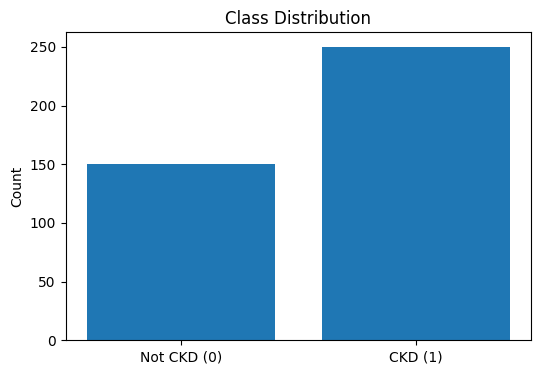

In [25]:
print("=== Class Distribution ===")
print(df['classification'].value_counts())

plt.figure(figsize=(6,4))
plt.bar(['Not CKD (0)', 'CKD (1)'],
        df['classification'].value_counts().sort_index().values)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

The dataset shows class imbalance between CKD and non-CKD cases.
This can bias the model toward the majority class, which is problematic in medical diagnosis.
Therefore, balancing techniques like SMOTE will be applied later during model training.

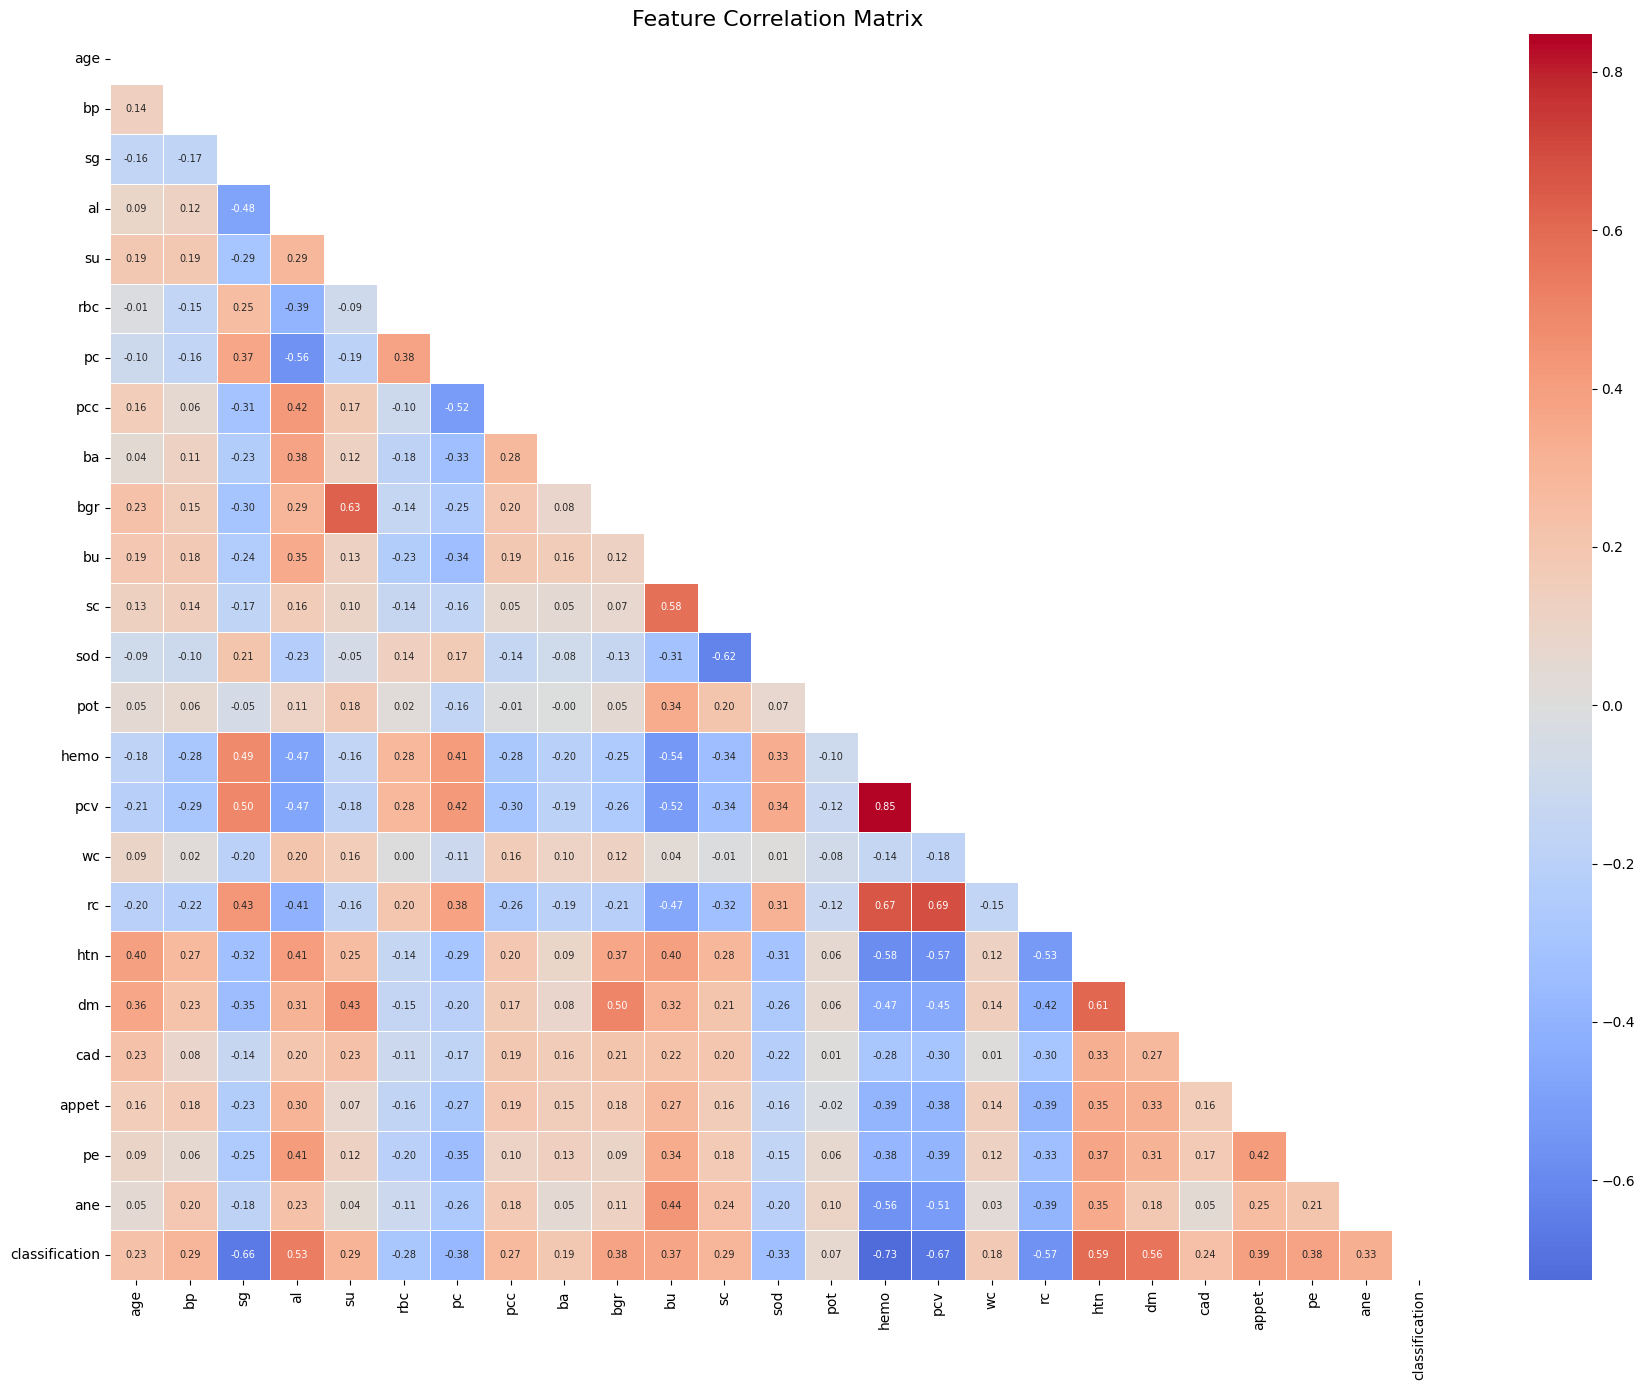

=== Highly Correlated Pairs (|r| >= 0.85) ===
No pairs above 0.85 found — using 0.75 threshold instead
  pcv <-> hemo: 0.847


In [26]:
plt.figure(figsize=(18, 14))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Find pairs above 0.85
print("=== Highly Correlated Pairs (|r| >= 0.85) ===")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.85:
            ci, cj = corr_matrix.columns[i], corr_matrix.columns[j]
            high_corr_pairs.append((ci, cj, round(val, 3)))
            print(f"  {ci} <-> {cj}: {val:.3f}")

if not high_corr_pairs:
    print("No pairs above 0.85 found — using 0.75 threshold instead")
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            val = corr_matrix.iloc[i, j]
            if abs(val) >= 0.75:
                ci, cj = corr_matrix.columns[i], corr_matrix.columns[j]
                high_corr_pairs.append((ci, cj, round(val, 3)))
                print(f"  {ci} <-> {cj}: {val:.3f}")

In [28]:
# Feature Selection (Correlation-based)

X = df.drop(columns=['classification'])
y = df['classification']

# Create correlation matrix
corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Set threshold
threshold = 0.75

# Find features to drop
cols_to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Create datasets
X_full = X.copy()
X_reduced = X.drop(columns=cols_to_drop)

# Print results
print(f"Full dataset:    {X_full.shape[1]} features")
print(f"Reduced dataset: {X_reduced.shape[1]} features")
print(f"Dropped cols:    {cols_to_drop if cols_to_drop else 'None'}")

Full dataset:    24 features
Reduced dataset: 23 features
Dropped cols:    ['pcv']


Correlation analysis was performed with a threshold of 0.85.

No feature pairs exceeded this threshold, indicating low multicollinearity.
Therefore, all features were retained in the full dataset.

For comparison purposes, a slightly lower threshold (0.75) was also explored.

In [29]:
df_full = X_full.copy()
df_full['classification'] = y

df_reduced = X_reduced.copy()
df_reduced['classification'] = y

df_full.to_csv("../data/processed/kidney_full.csv", index=False)
df_reduced.to_csv("../data/processed/kidney_reduced.csv", index=False)